In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../pyCudaPolygon"))
import pyCudaPolygon as pcp
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from pyCudaPolygonLink import libpyCudaPolygon as lpcp

In [2]:
maxSteps = 10000

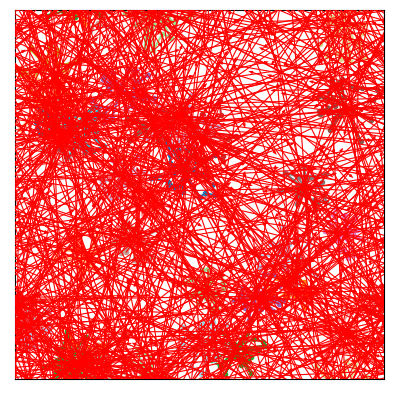

In [3]:
numPolygons = 32
n = 32
nVals = [0, 1, 2, 3, 9, 4 ,5, 6, 20, 25, 35, 54]
i = 5
phi = 0.05
kappa = 3.7
m = pcp.model(size = n * numPolygons, seed = i)
m.setModelEnum("edgeOnly")

m.generateRandomPolygons(numPolygons, n)
m.setBiPerimeters(kappa)
m.setStiffness(10)

m.initializeNeighborCells()
m.updateNeighborCells()
m.updateNeighbors()
m.updateOutersections()
m.updateForceEnergy()
force = m.getForces()
m.updateConstraintForces()
force0 = m.getConstraintForces()
positions0 = m.getPositions()
artists = m.draw(forces = force0)

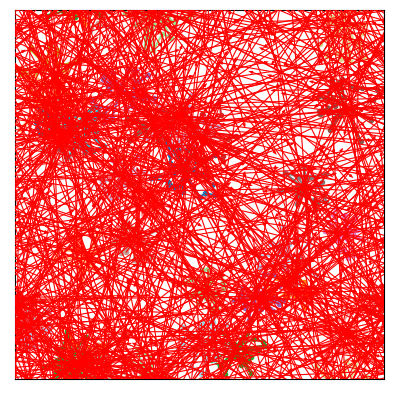

In [4]:
m.resetAreas()
m.updatePolygonGeometry()
areas = m.getAreas()
m.initializeNeighborCells()
m.updateNeighborCells()
m.updateNeighbors()
m.updateOutersections()
m.updateForceEnergy()
force = m.getForces()
m.updateConstraintForces()
force0 = m.getConstraintForces()
positions0 = m.getPositions()
artists = m.draw(forces = force0)
m.updateForceEnergy()

In [96]:
m.setModelEnum("edgeOnly")
m.minimizeGD(dt = 1e-2, maxSteps = maxSteps, progressBar = True)

Processing: 100%|████████████████████████| 10000/10000 [00:17<00:00, 578.51it/s]


In [97]:
m.getMaxUnbalancedForce()

3.542018071991448e-07

In [98]:
p0 = m.getTargetEdgeLengths()[0] * m.getnArray()[0]

In [99]:
p0 / np.sqrt(m.getAreas()[0])

3.699999999999994

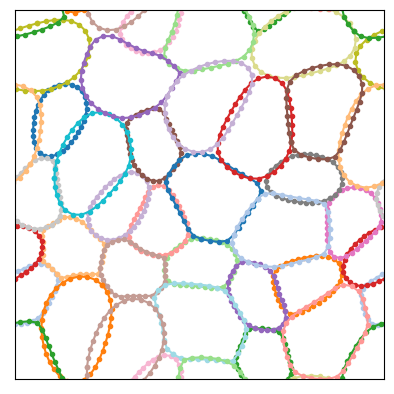

In [100]:
phi = 1.0
m.setPhi(phi)
_ = m.draw()

In [101]:
m.setModelEnum("normal")
m.minimizeGD(dt = 1e-2, maxSteps = maxSteps, progressBar = True)

Processing: 100%|████████████████████████| 10000/10000 [00:18<00:00, 538.34it/s]


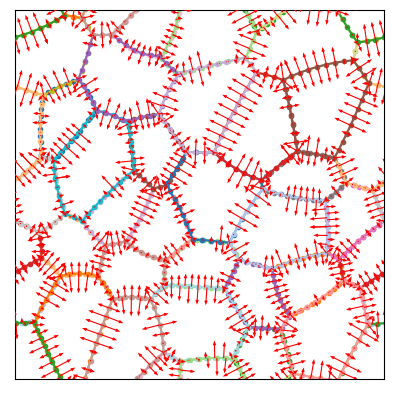

In [102]:
m.initializeNeighborCells()
m.updateNeighborCells()
m.updateNeighbors()
m.updateOutersections()
m.updateForceEnergy()
force = m.getForces()
m.updateConstraintForces()
force0 = m.getConstraintForces()
positions0 = m.getPositions()# Now you have dA, can you draw arrows on the vertices?
artists = m.draw(forces = force, arrowColor = 'r')

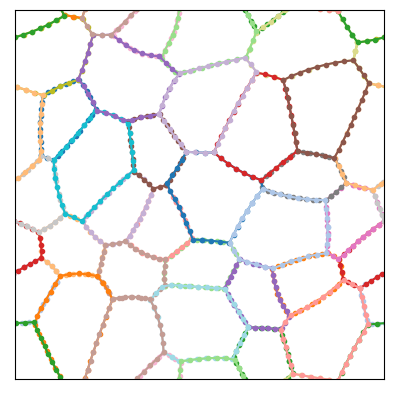

In [103]:
_ = m.draw()

In [104]:
m.updatePolygonGeometry()
print(m.getAreas())

[0.02111486 0.02111486 0.02111486 0.02111486 0.02111486 0.02111486
 0.02111486 0.02111486 0.02111486 0.02111486 0.02111486 0.02111486
 0.02111486 0.02111486 0.02111486 0.02111486 0.04138514 0.04138514
 0.04138514 0.04138514 0.04138514 0.04138514 0.04138514 0.04138514
 0.04138514 0.04138514 0.04138514 0.04138514 0.04138514 0.04138514
 0.04138514 0.04138514]


In [105]:
m.getMaxUnbalancedForce()

0.033590823897823356

In [106]:
np.mean(m.getAreas()), np.std(m.getAreas())

(0.031250000000000014, 0.010135135135135148)

In [107]:
m.saveModel("badForces", overwrite = True)

In [108]:
0.7147665882227807

0.7147665882227807